<a href="https://colab.research.google.com/github/manuelnunez-design/Actividad6_ML_Cancer_de_Piel/blob/main/Act_6_cancer_piel_ml_JMNL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<div align="center">

<img src="https://upload.wikimedia.org/wikipedia/commons/6/65/Universidad_Tecmilenio.png" width="220">

# Gestión de Proyectos de Inteligencia Artificial

## Actividad 6

### Evaluación y Validación de Modelos de Machine Learning para Cáncer de Piel


---

| Información | Detalle |
|------------|---------|
| **Alumno(a)** | Jesús Manuel Núñez López |
| **Matrícula** | AL07145363 |
| **Docente** | M. en C. Luis Ariel Vázquez Piña |
| **Materia** | Gestión de Proyectos de Inteligencia Artificial |
| **Actividad** | Actividad 6 |
| **Fecha de entrega** | 28 / 06 / 2026 |

---

### Universidad Tecmilenio  
#### Master en Inteligencia Artificial Aplicada

</div>


# Evaluación y validación de modelos de Machine Learning para cáncer de piel

**Caso de estudio:** clasificación binaria de lesiones cutáneas usando datos tabulares clínicos y morfológicos.

**Clases:**
- `0`: benigna / no sospechosa (`NEV`, `SEK`)
- `1`: sospechosa / maligna (`ACK`, `BCC`, `SCC`, `MEL`)

Este notebook utiliza Machine Learning clásico, no Deep Learning. No se procesan imágenes; se emplea únicamente el archivo `metadata.csv`.

## 1. Importación de librerías

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)
from scipy.stats import wilcoxon

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({"font.size": 10, "figure.dpi": 140})

## 2. Carga del dataset

Se cargó el archivo `metadata.csv` al entorno de Colab

In [2]:
DATA_PATH = "metadata.csv"

df = pd.read_csv(DATA_PATH)

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (2298, 26)


,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,...,NaN,ACK,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,TRUE,TRUE,FALSE,FALSE,TRUE,TRUE,PAT_684_1302_588.png,True


## 3. Revisión inicial del dataset

In [3]:
print("Columnas disponibles:")
print(df.columns.tolist())

print("\nDistribución del diagnóstico original:")
print(df["diagnostic"].value_counts())

print("\nValores faltantes por columna:")
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Columnas disponibles:
['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father', 'background_mother', 'age', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick', 'region', 'diameter_1', 'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'img_id', 'biopsed']

Distribución del diagnóstico original:
diagnostic
BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: count, dtype: int64

Valores faltantes por columna:


,0
background_mother,822
background_father,818
pesticide,804
gender,804
drink,804
smoke,804
skin_cancer_history,804
has_sewage_system,804
has_piped_water,804
cancer_history,804


## 4. Construcción de la variable objetivo

Se convierte el problema original multiclase en una clasificación binaria.

- `NEV` y `SEK`: lesiones benignas/no sospechosas.
- `ACK`, `BCC`, `SCC` y `MEL`: lesiones sospechosas/malignas.

`ACK` se incluye como sospechosa por ser una lesión clínicamente relevante y precancerosa.

In [4]:
diagnosticos_sospechosos = ["ACK", "BCC", "SCC", "MEL"]
diagnosticos_benignos = ["NEV", "SEK"]

df["target"] = df["diagnostic"].isin(diagnosticos_sospechosos).astype(int)

print(df["target"].value_counts())
print("\n0 = Benigna / no sospechosa")
print("1 = Sospechosa / maligna")

target
1    1819
0     479
Name: count, dtype: int64

0 = Benigna / no sospechosa
1 = Sospechosa / maligna


## 5. Análisis exploratorio de datos

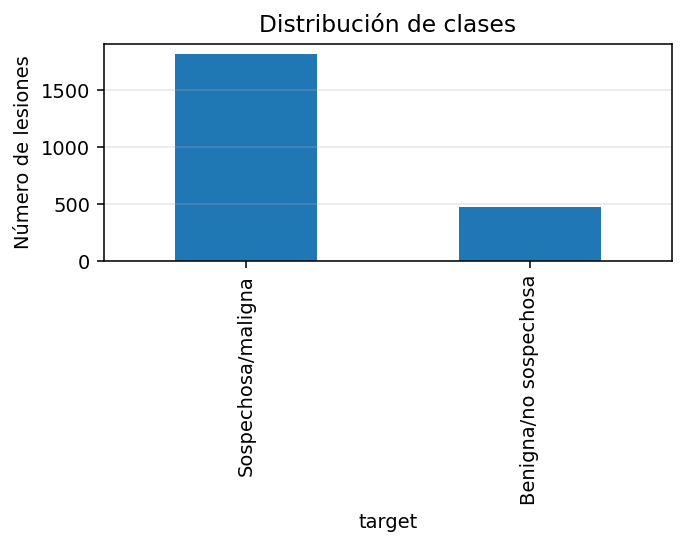

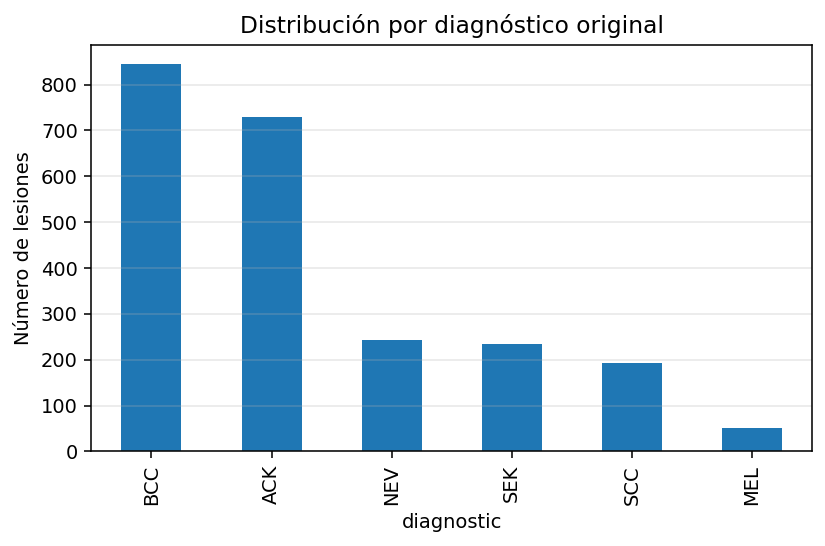

In [5]:
plt.figure(figsize=(5,4))
df["target"].map({0:"Benigna/no sospechosa", 1:"Sospechosa/maligna"}).value_counts().plot(kind="bar")
plt.title("Distribución de clases")
plt.ylabel("Número de lesiones")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
df["diagnostic"].value_counts().plot(kind="bar")
plt.title("Distribución por diagnóstico original")
plt.ylabel("Número de lesiones")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

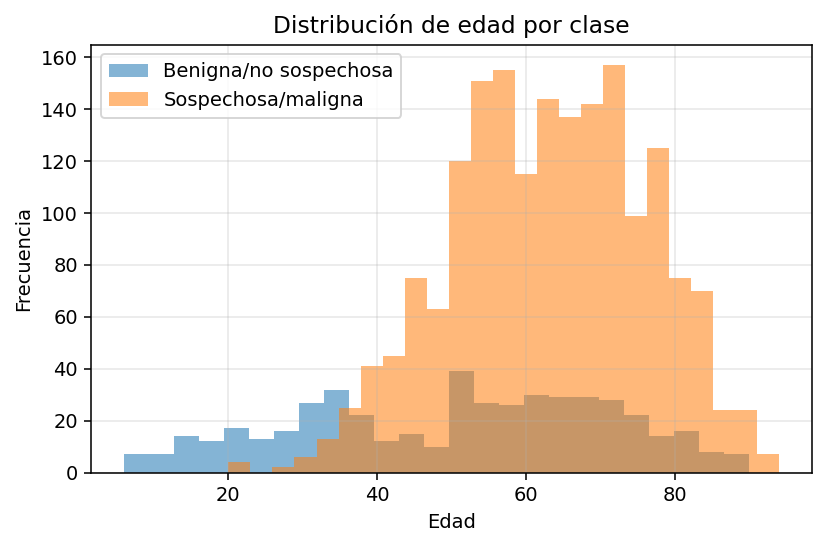

In [6]:
# Distribución de edad por clase
plt.figure(figsize=(6,4))
for clase, nombre in [(0, "Benigna/no sospechosa"), (1, "Sospechosa/maligna")]:
    plt.hist(df.loc[df["target"] == clase, "age"], bins=25, alpha=0.55, label=nombre)
plt.title("Distribución de edad por clase")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Selección de variables y prevención de fuga de información

Se eliminan identificadores y variables que podrían generar fuga de información, como `biopsed`, ya que puede estar relacionada con la decisión clínica posterior al diagnóstico.

In [7]:
columnas_excluir = [
    "patient_id",
    "lesion_id",
    "img_id",
    "diagnostic",
    "biopsed",
    "target"
]

X = df.drop(columns=columnas_excluir)
y = df["target"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Variables numéricas:", numeric_features)
print("Variables categóricas:", categorical_features)
print("Dimensiones de X:", X.shape)

Variables numéricas: ['age', 'fitspatrick', 'diameter_1', 'diameter_2']
Variables categóricas: ['smoke', 'drink', 'background_father', 'background_mother', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'region', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation']
Dimensiones de X: (2298, 21)


## 7. Preprocesamiento

El preprocesamiento se realiza dentro de un `Pipeline` para evitar fuga de información.

- Variables numéricas: imputación con mediana y escalado.
- Variables categóricas: imputación con moda y codificación One-Hot.

In [8]:
numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_scaled = ColumnTransformer(transformers=[
    ("num", numeric_transformer_scaled, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

preprocessor_tree = ColumnTransformer(transformers=[
    ("num", numeric_transformer_tree, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## 8. División entrenamiento/prueba

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (1838, 21)
Prueba: (460, 21)


## 9. Definición de modelos

Se utilizan tres modelos clásicos de Machine Learning:

1. Regresión Logística.
2. Random Forest.
3. Gradient Boosting.

In [10]:
models = {
    "Regresión Logística": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", LogisticRegression(
            max_iter=1500,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", RandomForestClassifier(
            n_estimators=80,
            max_depth=8,
            min_samples_leaf=4,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=RANDOM_STATE
        ))
    ])
}

models.keys()

dict_keys(['Regresión Logística', 'Random Forest', 'Gradient Boosting'])

## 10. Entrenamiento y evaluación en conjunto de prueba

In [11]:
results = []
trained_models = {}

for name, model in models.items():
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    start_pred = time.time()
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    inference_time = time.time() - start_pred

    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "Tiempo entrenamiento (s)": train_time,
        "Tiempo inferencia (s)": inference_time
    })

    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values("F1-score", ascending=False)
results_df

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,Tiempo entrenamiento (s),Tiempo inferencia (s)
2,Gradient Boosting,0.915217,0.928760,0.967033,0.947510,0.945599,0.416442,0.026899
1,Random Forest,0.856522,0.954268,0.859890,0.904624,0.942451,0.316040,0.076902
0,Regresión Logística,0.847826,0.959375,0.843407,0.897661,0.938616,0.097685,0.028289


## 11. Selección del mejor modelo

In [12]:
best_name = results_df.iloc[0]["Modelo"]
best_model = trained_models[best_name]

print("Mejor modelo seleccionado:", best_name)

Mejor modelo seleccionado: Gradient Boosting


## 12. Matriz de confusión

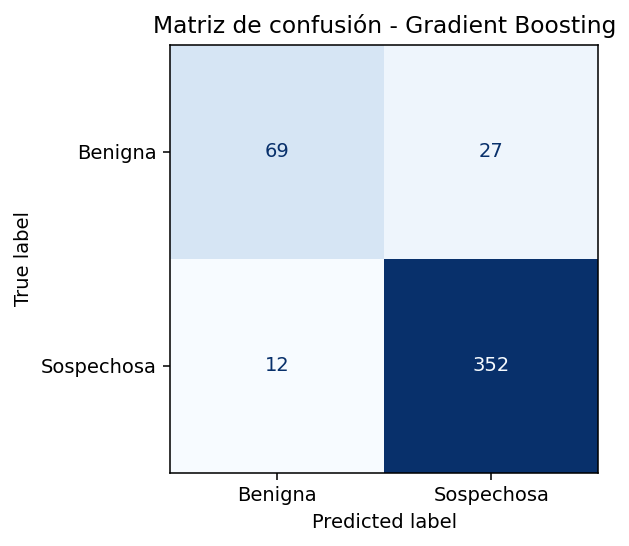

              precision    recall  f1-score   support

     Benigna       0.85      0.72      0.78        96
  Sospechosa       0.93      0.97      0.95       364

    accuracy                           0.92       460
   macro avg       0.89      0.84      0.86       460
weighted avg       0.91      0.92      0.91       460



In [13]:
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benigna", "Sospechosa"]
)

fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title(f"Matriz de confusión - {best_name}")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_best, target_names=["Benigna", "Sospechosa"]))

## 13. Ajuste del umbral de decisión

El umbral por defecto es 0.50. En un contexto clínico puede ser útil reducirlo si se desea aumentar el Recall de la clase sospechosa.

In [14]:
y_proba_best = best_model.predict_proba(X_test)[:, 1]

threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.10):
    y_pred_threshold = (y_proba_best >= threshold).astype(int)

    threshold_rows.append({
        "Umbral": round(threshold, 2),
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1-score": f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df

,Umbral,Precision,Recall,F1-score
0,0.1,0.842593,1.000000,0.914573
1,0.2,0.872596,0.997253,0.930769
2,0.3,0.897500,0.986264,0.939791
3,0.4,0.905852,0.978022,0.940555
4,0.5,0.928760,0.967033,0.947510
5,0.6,0.938719,0.925824,0.932227
6,0.7,0.945402,0.903846,0.924157
7,0.8,0.962500,0.846154,0.900585
8,0.9,0.981550,0.730769,0.837795


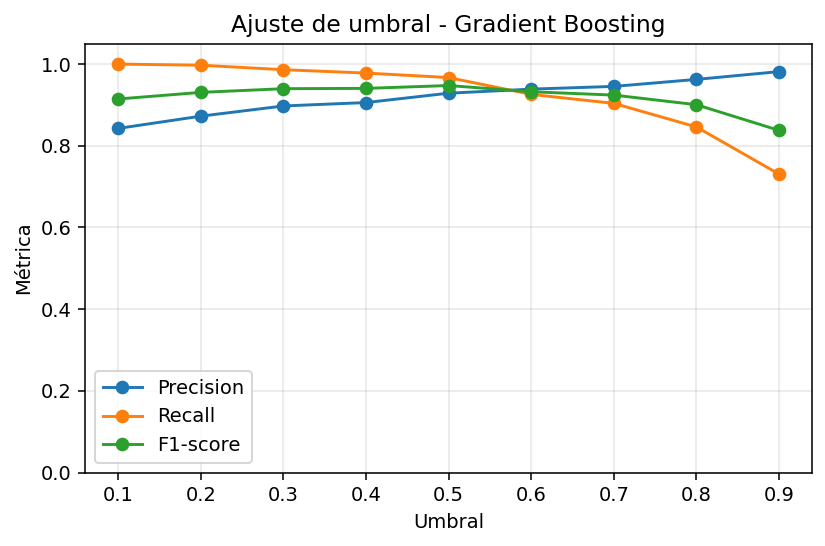

In [15]:
plt.figure(figsize=(6,4))
for metric in ["Precision", "Recall", "F1-score"]:
    plt.plot(threshold_df["Umbral"], threshold_df[metric], marker="o", label=metric)

plt.title(f"Ajuste de umbral - {best_name}")
plt.xlabel("Umbral")
plt.ylabel("Métrica")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 14. Validación cruzada estratificada

In [16]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_rows = []
fold_f1_scores = {}

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=1
    )

    fold_f1_scores[name] = scores["test_f1"]

    row = {"Modelo": name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()

    cv_rows.append(row)

cv_df = pd.DataFrame(cv_rows).sort_values("f1_mean", ascending=False)
cv_df

,Modelo,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
2,Gradient Boosting,0.915576,0.008654,0.919969,0.008215,0.978561,0.006357,0.948330,0.005177,0.949467,0.012516
1,Random Forest,0.891633,0.015801,0.960489,0.011807,0.900504,0.025882,0.929200,0.011328,0.952226,0.009320
0,Regresión Logística,0.865098,0.014045,0.959222,0.005201,0.866415,0.016314,0.910385,0.009935,0.938915,0.010108


## 15. Curva ROC usando predicciones de validación cruzada

La curva ROC se construye con probabilidades fuera de muestra obtenidas mediante `cross_val_predict`.
Esto significa que cada predicción fue realizada por un modelo que no vio ese registro durante entrenamiento.

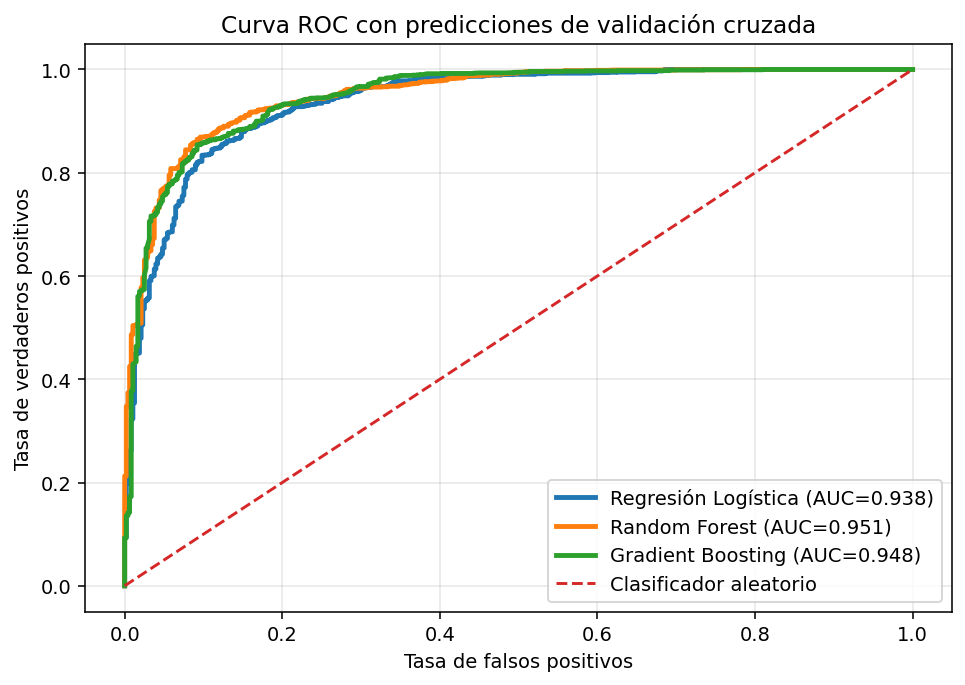

,Modelo,AUC_CV
0,Regresión Logística,0.938327
1,Random Forest,0.950729
2,Gradient Boosting,0.948224


In [17]:
plt.figure(figsize=(7,5))
roc_rows = []

for name, model in models.items():
    y_proba_cv = cross_val_predict(
        model,
        X,
        y,
        cv=cv,
        method="predict_proba",
        n_jobs=1
    )[:, 1]

    fpr, tpr, _ = roc_curve(y, y_proba_cv)
    auc_value = auc(fpr, tpr)

    roc_rows.append({"Modelo": name, "AUC_CV": auc_value})

    plt.plot(
        fpr,
        tpr,
        linewidth=2.5,
        label=f"{name} (AUC={auc_value:.3f})"
    )

plt.plot([0, 1], [0, 1], "--", linewidth=1.5, label="Clasificador aleatorio")
plt.title("Curva ROC con predicciones de validación cruzada")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

roc_cv_df = pd.DataFrame(roc_rows)
roc_cv_df

## 16. Comparación visual de modelos

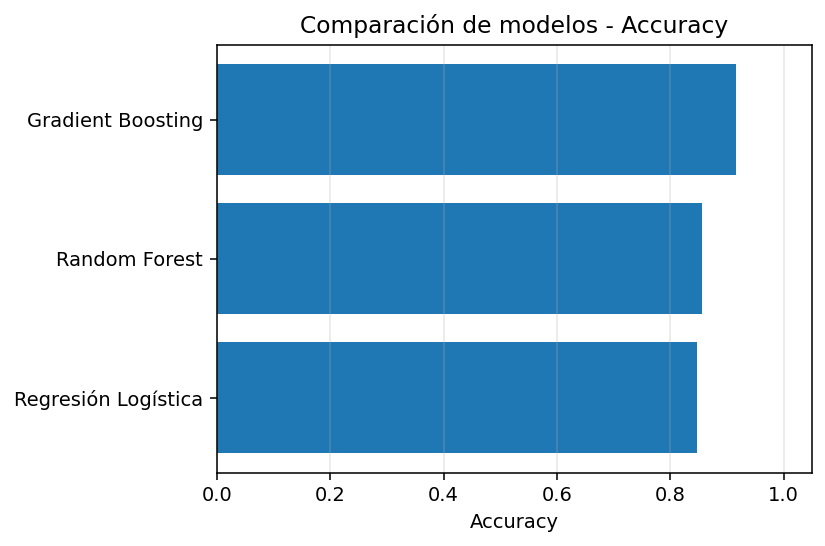

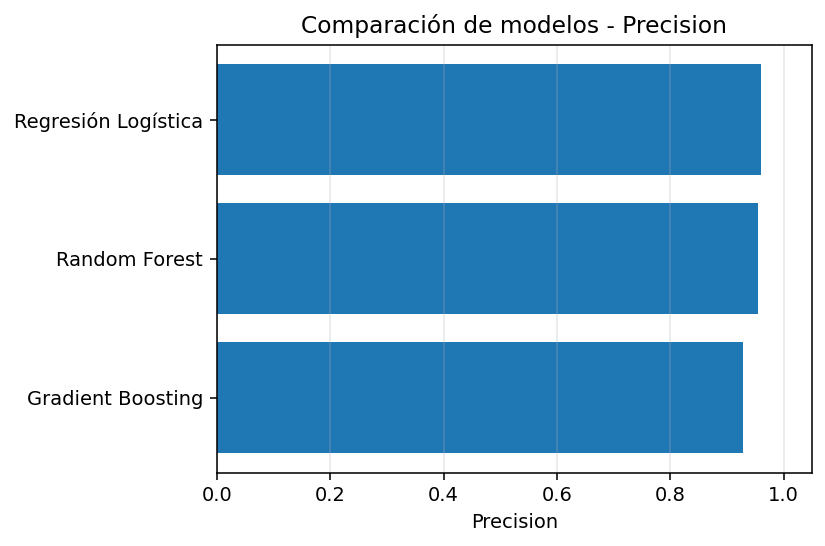

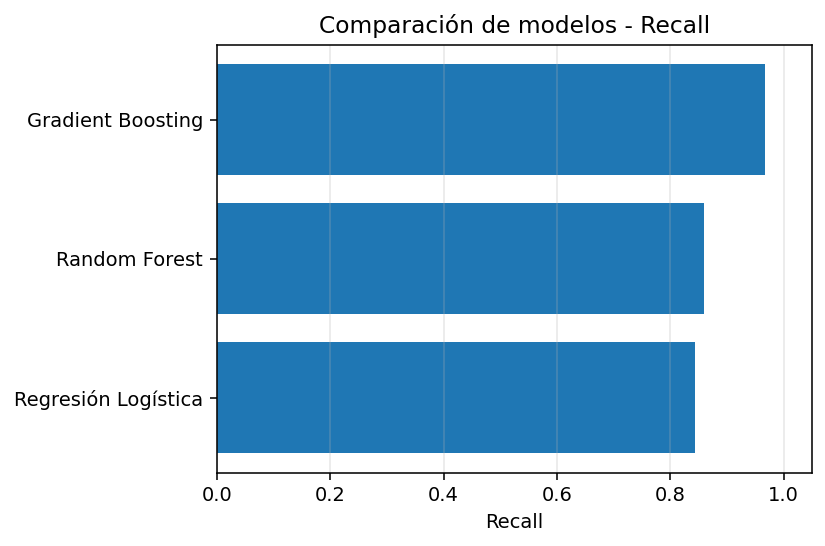

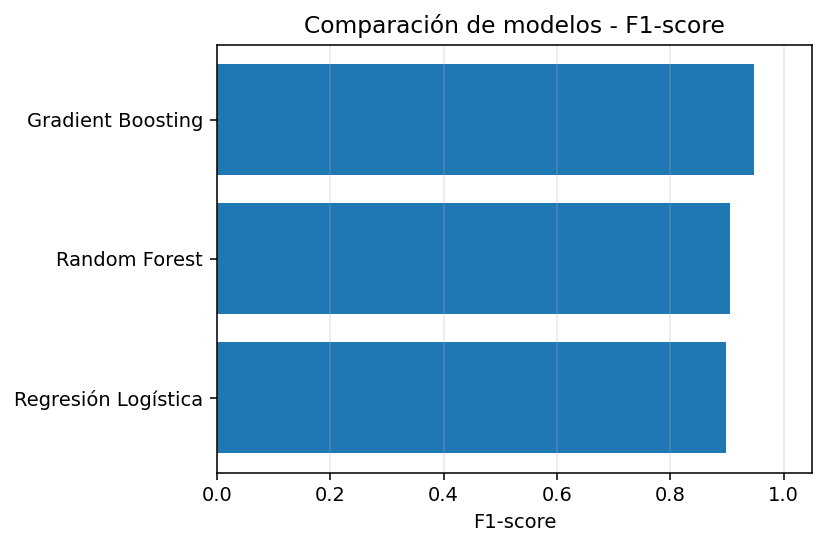

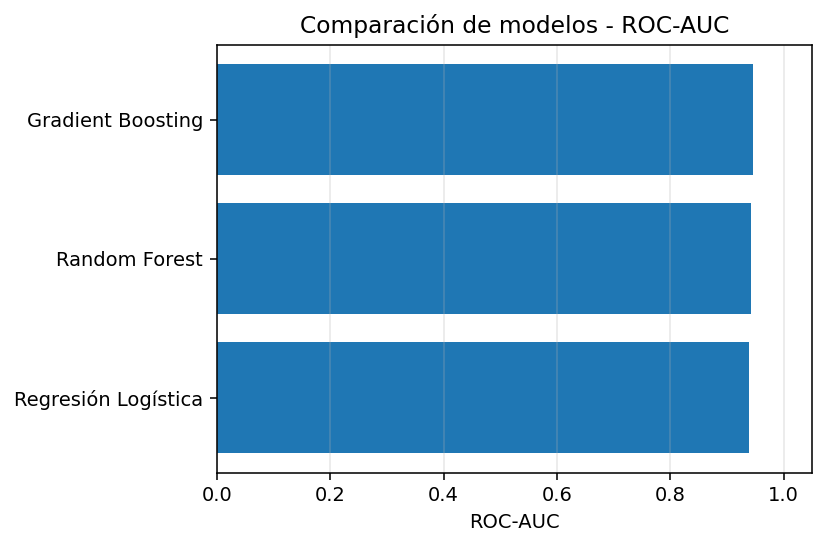

In [18]:
metric_cols = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

for metric in metric_cols:
    plt.figure(figsize=(6,4))
    temp = results_df.sort_values(metric)
    plt.barh(temp["Modelo"], temp[metric])
    plt.xlim(0, 1.05)
    plt.xlabel(metric)
    plt.title(f"Comparación de modelos - {metric}")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

## 17. Prueba A/B entre los dos mejores modelos

In [19]:
top2 = cv_df["Modelo"].head(2).tolist()
model_A_name = top2[0]
model_B_name = top2[1]

print("Modelo A:", model_A_name)
print("Modelo B:", model_B_name)

ab_df = results_df[results_df["Modelo"].isin(top2)].copy()
ab_df

Modelo A: Gradient Boosting
Modelo B: Random Forest


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,Tiempo entrenamiento (s),Tiempo inferencia (s)
2,Gradient Boosting,0.915217,0.928760,0.967033,0.947510,0.945599,0.416442,0.026899
1,Random Forest,0.856522,0.954268,0.859890,0.904624,0.942451,0.316040,0.076902


## 18. Significancia estadística con Wilcoxon

Se comparan los F1-score obtenidos fold a fold en validación cruzada para los dos mejores modelos.

In [20]:
scores_A = fold_f1_scores[model_A_name]
scores_B = fold_f1_scores[model_B_name]

print("F1 por fold - Modelo A:", scores_A)
print("F1 por fold - Modelo B:", scores_B)

stat, p_value = wilcoxon(scores_A, scores_B)

print(f"Estadístico Wilcoxon: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Existe diferencia estadísticamente significativa entre los modelos.")
else:
    print("No se encontró diferencia estadísticamente significativa entre los modelos.")

F1 por fold - Modelo A: [0.94892473 0.94179894 0.95744681 0.94555113 0.94793057]
F1 por fold - Modelo B: [0.92528736 0.94182825 0.93883357 0.9301676  0.90988372]
Estadístico Wilcoxon: 1.0000
p-value: 0.1250
No se encontró diferencia estadísticamente significativa entre los modelos.


## 19. Importancia de variables con Random Forest

In [21]:
rf_model = trained_models["Random Forest"]

feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = rf_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": importances
}).sort_values("Importancia", ascending=False)

importance_df.head(15)

,Variable,Importancia
59,cat__itch_TRUE,0.160143
58,cat__itch_FALSE,0.132316
0,num__age,0.068595
70,cat__bleed_FALSE,0.049879
3,num__diameter_2,0.049870
71,cat__bleed_TRUE,0.048458
2,num__diameter_1,0.039131
33,cat__pesticide_True,0.035806
17,cat__background_father_POMERANIA,0.031960
74,cat__elevation_TRUE,0.028806


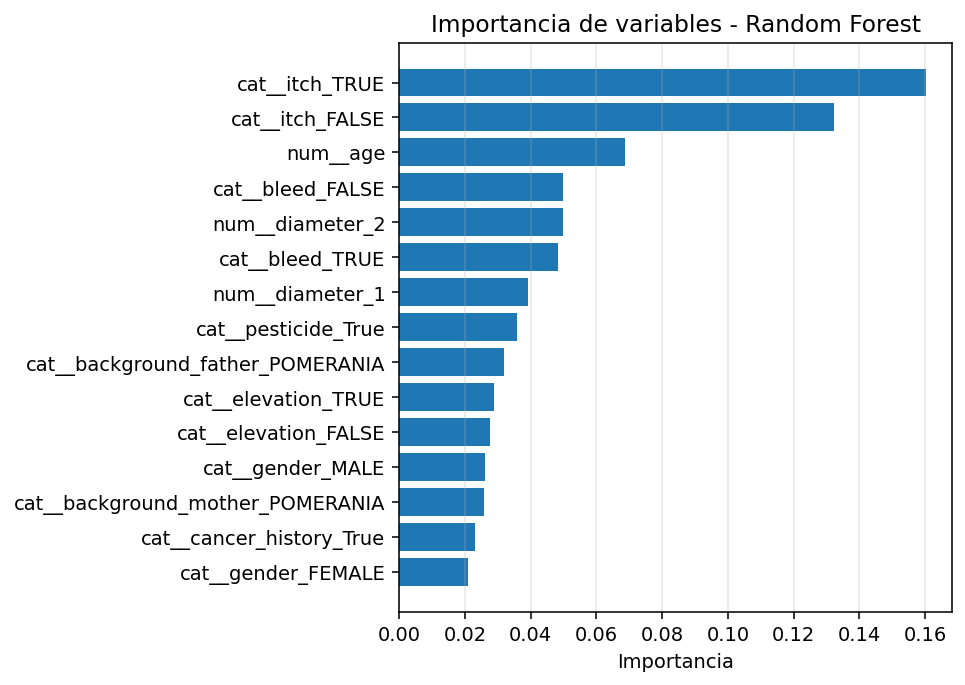

In [22]:
top_imp = importance_df.head(15).sort_values("Importancia")

plt.figure(figsize=(7,5))
plt.barh(top_imp["Variable"], top_imp["Importancia"])
plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 20. Registro de experimentos

In [23]:
experiment_log = results_df.copy()
experiment_log["Dataset"] = "PAD-UFES-20 metadata.csv"
experiment_log["Validación"] = "Train/Test + Stratified 5-Fold CV"
experiment_log["Modelo seleccionado"] = experiment_log["Modelo"] == best_name

experiment_log.to_csv("registro_experimentos_cancer_piel.csv", index=False)
experiment_log

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,Tiempo entrenamiento (s),Tiempo inferencia (s),Dataset,Validación,Modelo seleccionado
2,Gradient Boosting,0.915217,0.928760,0.967033,0.947510,0.945599,0.416442,0.026899,PAD-UFES-20 metadata.csv,Train/Test + Stratified 5-Fold CV,True
1,Random Forest,0.856522,0.954268,0.859890,0.904624,0.942451,0.316040,0.076902,PAD-UFES-20 metadata.csv,Train/Test + Stratified 5-Fold CV,False
0,Regresión Logística,0.847826,0.959375,0.843407,0.897661,0.938616,0.097685,0.028289,PAD-UFES-20 metadata.csv,Train/Test + Stratified 5-Fold CV,False


## 21. Conclusiones

- El caso de cáncer de piel permite evaluar modelos con métricas más realistas que el caso de anemia.
- Gradient Boosting obtuvo el mejor equilibrio entre Recall y F1-score.
- Random Forest presentó un ROC-AUC competitivo y permite interpretación mediante importancia de variables.
- La curva ROC con validación cruzada proporciona una evaluación más robusta de la capacidad discriminativa.
- En un contexto clínico, se recomienda priorizar Recall para reducir falsos negativos, sin interpretar el modelo como sustituto del diagnóstico médico.